In [7]:
import numpy as np
import glob
import os
import cv2
import matplotlib as mlp

In [3]:
folder_path = '/home/filelele/Pictures/floor3_normal/distortion_corrected_frames'
frame_paths = sorted(glob.glob(os.path.join(folder_path,'*.jpg' )))

In [10]:
import os
import glob
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Load map reference once
npz_path = os.path.expanduser("~/Pictures/floor3_normal/distortion_corrected_frames/occupancy_grid/map_reference.npz")
map_data = np.load(npz_path)
print(f"Loaded map reference: {len(map_data['positions'])} frames available (indices 0 to {len(map_data['positions']) - 1})")

def inspect_frame(frame_idx: int):
    total = len(map_data["positions"])
    if frame_idx < 0 or frame_idx >= total:
        print(f"Error: frame_idx must be between 0 and {total - 1}")
        return

    pos = map_data["positions"][frame_idx]
    yaw_rad = map_data["yaws"][frame_idx]
    yaw_deg = np.degrees(yaw_rad)
    img_path = str(map_data["image_paths"][frame_idx])
    c2w = map_data["c2w"][frame_idx]

    print(f"\n================ Frame {frame_idx} ================")
    print(f"Image Path : {img_path}")
    print(f"Position (meters): X = {pos[0]:.3f}, Y = {pos[1]:.3f}, Z = {pos[2]:.3f}")
    print(f"Heading (Yaw)    : {yaw_deg:.2f}° ({yaw_rad:.4f} rad)")
    print("Camera-to-World (c2w 4x4 matrix):")
    print(np.round(c2w, 4))

    img_bgr = cv2.imread(img_path)
    if img_bgr is not None:
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(9, 5))
        plt.imshow(img_rgb)
        plt.title(f"Frame {frame_idx} | Pos: ({pos[0]:.2f}m, {pos[2]:.2f}m) | Yaw: {yaw_deg:.1f}°")
        plt.axis("off")
        plt.show()
    else:
        print(f"Could not load image from: {img_path}")


Loaded map reference: 144 frames available (indices 0 to 143)



================ Frame 3 ================
Image Path : /home/filelele/Pictures/floor3_normal/distortion_corrected_frames/capture_20260921_231232_246.jpg
Position (meters): X = 0.055, Y = 0.013, Z = -0.213
Heading (Yaw)    : -10.24° (-0.1787 rad)
Camera-to-World (c2w 4x4 matrix):
[[ 0.984   0.0081 -0.1778  0.0552]
 [-0.0078  1.      0.0025  0.0135]
 [ 0.1778 -0.0011  0.9841 -0.2126]
 [ 0.      0.      0.      1.    ]]


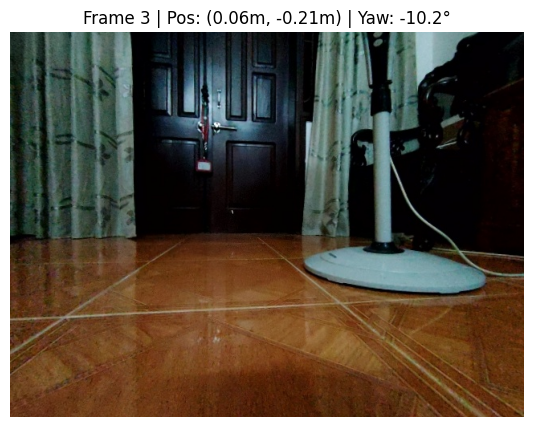


================ Frame 30 ================
Image Path : /home/filelele/Pictures/floor3_normal/distortion_corrected_frames/capture_20260921_231357_445.jpg
Position (meters): X = 0.333, Y = 0.089, Z = -1.381
Heading (Yaw)    : 32.75° (0.5715 rad)
Camera-to-World (c2w 4x4 matrix):
[[ 0.8408 -0.0213  0.5409  0.3327]
 [ 0.0244  0.9997  0.0014  0.0886]
 [-0.5408  0.012   0.8411 -1.3815]
 [ 0.      0.      0.      1.    ]]


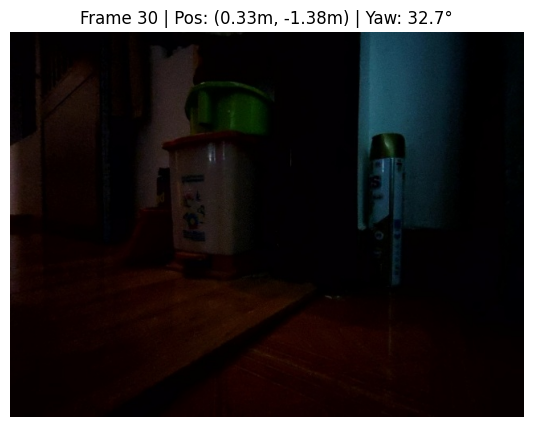


================ Frame 40 ================
Image Path : /home/filelele/Pictures/floor3_normal/distortion_corrected_frames/capture_20260921_231426_078.jpg
Position (meters): X = -1.280, Y = 0.040, Z = -0.532
Heading (Yaw)    : 113.03° (1.9728 rad)
Camera-to-World (c2w 4x4 matrix):
[[-0.3936 -0.0472  0.9181 -1.2803]
 [ 0.0415  0.9967  0.0691  0.0395]
 [-0.9184  0.0653 -0.3903 -0.5316]
 [ 0.      0.      0.      1.    ]]


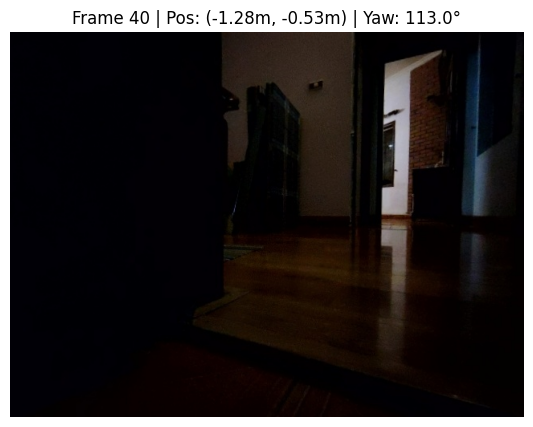


================ Frame 60 ================
Image Path : /home/filelele/Pictures/floor3_normal/distortion_corrected_frames/capture_20260921_231526_713.jpg
Position (meters): X = -1.790, Y = 0.174, Z = -3.826
Heading (Yaw)    : 97.75° (1.7061 rad)
Camera-to-World (c2w 4x4 matrix):
[[-0.1372 -0.0538  0.9891 -1.79  ]
 [ 0.0409  0.9974  0.0599  0.1745]
 [-0.9897  0.0487 -0.1346 -3.826 ]
 [ 0.      0.      0.      1.    ]]


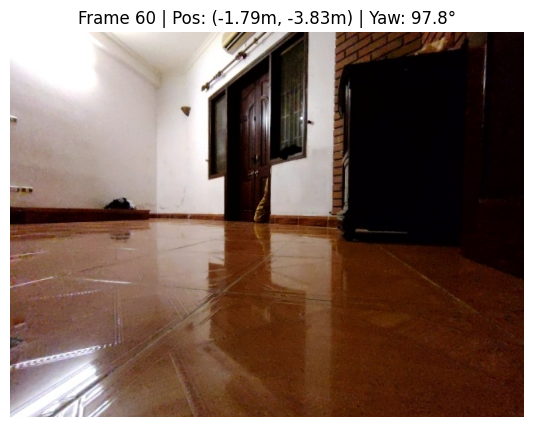


================ Frame 90 ================
Image Path : /home/filelele/Pictures/floor3_normal/distortion_corrected_frames/capture_20260921_231659_599.jpg
Position (meters): X = -0.651, Y = 0.512, Z = -7.697
Heading (Yaw)    : 101.43° (1.7702 rad)
Camera-to-World (c2w 4x4 matrix):
[[-0.2013 -0.056   0.9779 -0.651 ]
 [ 0.0522  0.9963  0.0678  0.512 ]
 [-0.9781  0.0647 -0.1977 -7.6966]
 [ 0.      0.      0.      1.    ]]


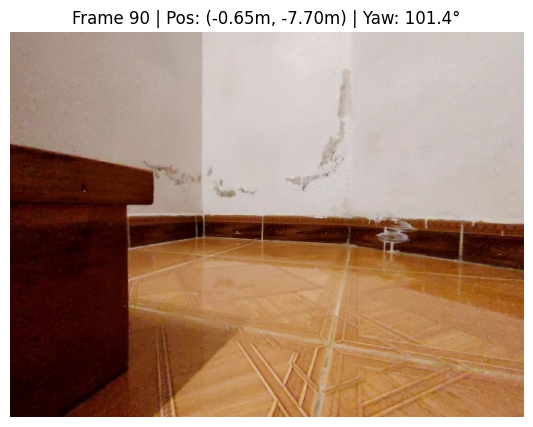

(None, None, None, None, None)

In [44]:
inspect_frame(3), inspect_frame(30), inspect_frame(40), inspect_frame(60), inspect_frame(90)

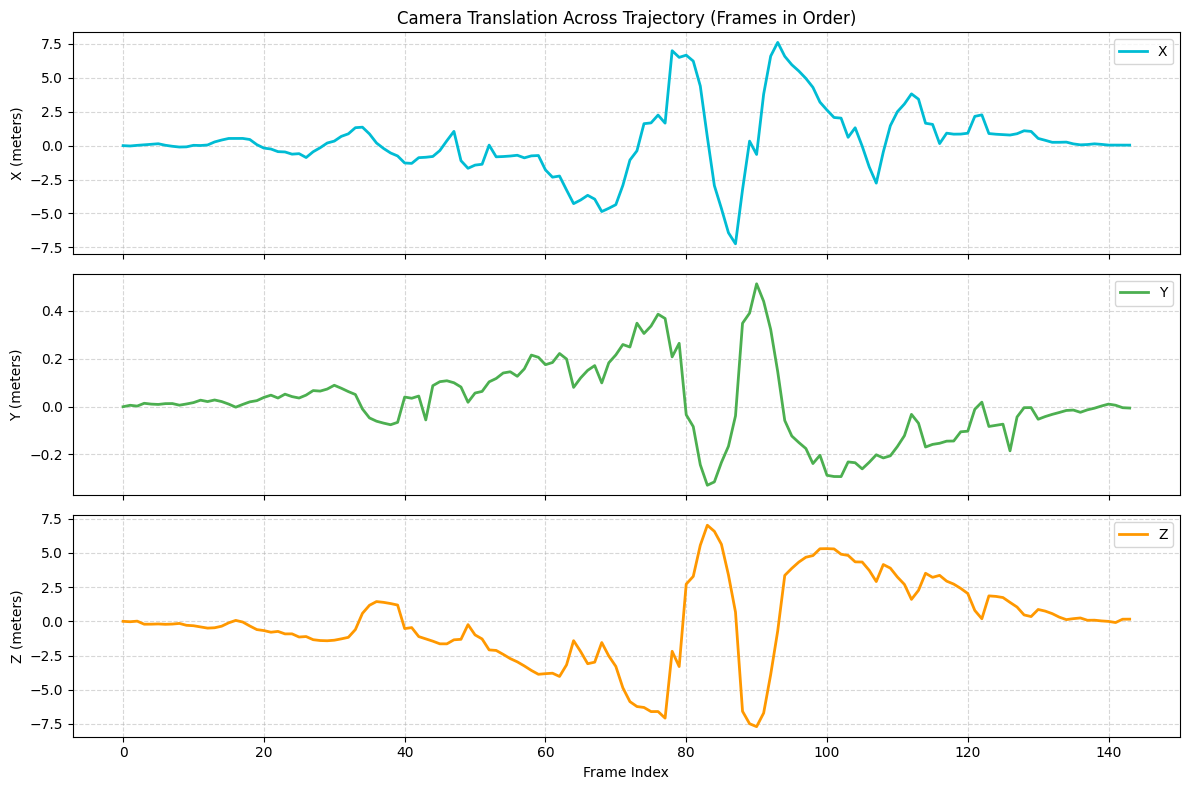

In [ ]:
positions = map_data["positions"]  # shape [N, 3]
frame_indices = np.arange(len(positions))

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# Plot X (Right / Left)
axes[0].plot(frame_indices, positions[:, 0], color="#00bcd4", linewidth=2, label="X")
axes[0].set_ylabel("X (meters)")
axes[0].set_title("Camera Translation Across Trajectory (Frames in Order)")
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].legend(loc="upper right")

# Plot Y (Down / Up)
axes[1].plot(frame_indices, positions[:, 1], color="#4caf50", linewidth=2, label="Y")
axes[1].set_ylabel("Y (meters)")
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].legend(loc="upper right")

# Plot Z (Forward / Back)
axes[2].plot(frame_indices, positions[:, 2], color="#ff9800", linewidth=2, label="Z")
axes[2].set_ylabel("Z (meters)")
axes[2].set_xlabel("Frame Index")
axes[2].grid(True, linestyle="--", alpha=0.5)
axes[2].legend(loc="upper right")

plt.tight_layout()
plt.show()


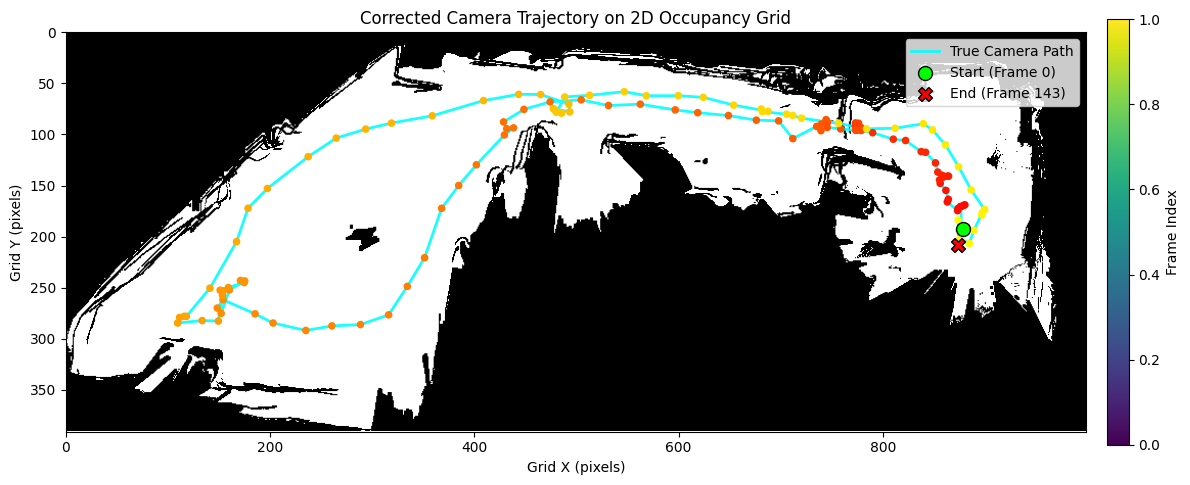

In [49]:
import os
import yaml
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load map image and YAML metadata
map_dir = os.path.expanduser("~/Pictures/floor3_normal/distortion_corrected_frames/occupancy_grid")
png_path = os.path.join(map_dir, "occupancy_grid.png")
yaml_path = os.path.join(map_dir, "occupancy_grid.yaml")
npz_path = os.path.join(map_dir, "map_reference.npz")

grid_img = cv2.imread(png_path, cv2.IMREAD_GRAYSCALE)
with open(yaml_path, "r") as f:
    map_meta = yaml.safe_load(f)

res = float(map_meta["resolution"])
origin_x = float(map_meta["origin"][0])
origin_z = float(map_meta["origin"][1])
data = np.load(npz_path)

# 2. Compute TRUE camera world position: C = - R.T @ t
c2w_raw = data["c2w"]  # [N, 4, 4]
R = c2w_raw[:, :3, :3]
t = c2w_raw[:, :3, 3:]

true_positions = -np.einsum('nij,njk->nik', R.transpose(0, 2, 1), t).squeeze(-1)

# 3. Convert true positions (meters) to map pixels
traj_px_x = (true_positions[:, 0] - origin_x) / res
traj_px_y = (grid_img.shape[0] - 1) - (true_positions[:, 2] - origin_z) / res

# 4. Plot
plt.figure(figsize=(12, 6))
plt.imshow(grid_img, cmap="gray", origin="upper")

plt.plot(traj_px_x, traj_px_y, color="cyan", linewidth=2.0, alpha=0.9, label="True Camera Path")
plt.scatter(traj_px_x, traj_px_y, c=np.arange(len(true_positions)), cmap="autumn", s=20, zorder=3)

plt.scatter(traj_px_x[0], traj_px_y[0], color="lime", s=100, marker="o", edgecolors="black", label="Start (Frame 0)", zorder=4)
plt.scatter(traj_px_x[-1], traj_px_y[-1], color="red", s=100, marker="X", edgecolors="black", label="End (Frame 143)", zorder=4)

plt.title("Corrected Camera Trajectory on 2D Occupancy Grid")
plt.xlabel("Grid X (pixels)")
plt.ylabel("Grid Y (pixels)")
plt.xlim(0, grid_img.shape[1])
plt.ylim(grid_img.shape[0], 0)
plt.legend(loc="upper right")
plt.colorbar(label="Frame Index", fraction=0.02, pad=0.02)
plt.tight_layout()
plt.show()
